# 🐱Феномен популярности книг о графе Аверине

**Идея исследования:**

*Серия книг о рассследованиях графа Аверина (офицальное название:
"Колдун Российской империи") завоевала сумасшедшую популярность после выхода в 2023 году. За 2024-2025 год ее популярность только увеличилась. Книги серии были выпущены огромными тиражами, активно представлены во всевозможных книжных рейтингах, а также стали трендами в соответствующих соц сетях и т. д. Важно, что книги серии стали востребованы у самых разных групп российской читательской аудитории. Этот тезис подкрепляется во-первых популярностью книг у всех поколений (начиная от зумеров и далее), а также у читателей, отдающих основное препочтение разным жанра, а во-вторых осторожным принятием книги кругами, отдающими предпочтение условно элитарным и классическим произведение (ряд других усойчивых бестселлеров условно массовой литературы подобным похвастаться скорее не может). Кроме того, данная серия книг вызвала поток детективных серий и книг в имперском сеттинге в разных издательствах.*

Такая ситуация сделала данную серию книг особенно ярким представителем современного книжного рынка (условно массовой литературы) и интересным обьектом для исследования в области современной гуманитарной науки.

Материалом для исследования будут три первые книги серии (на данный момент существует 5 книг).

В фокусе исследования будет применение цифровых методов гуманитарной науки для лучшего понимания, что из себя представляет серия книг "Колдун Российской империи".

**Цель:** провести цифровой анализ серии книг "Граф Аверин" через изучение специфики и значимых акцентов серии, ее развития от книги к книге и ее образа в сопоставлении.

**План работы и задачи:**

1) Провести токенизацию и лемматизацию текстов трех книг

2) Выявить наиболее популярные слова в трех книгах, вывести результаты в виде облаков слов и диаграмм

3) Вычислить индекс Флэша для трех книг

4) Вычислить TTR для оценки лексического разнообразия книг

6) Посмотреть слова-маркеры для каждой книги, изменение роли разных слов от книги к книге, вычислить TF-IDF для трех книг

7) Провести сопоставление книги с книгами других авторов лдля выявления специфики книги в сравнении через методы стилометрии



**Немного ресурсов по теме:**

*Статья в Т-журнале: "Расследования графа Аверина: в чем причина популярности детективов о колдуне Российской империи"* (URL: https://t-j.ru/graf-averin/)

*Результаты первого года продаж от издательства (2023)* (URL: https://eksmo.ru/amp/news/roman-graf-averin-stal-khitom-2023-goda-12-23-ID15664197/)

*Обзор и интервью на ЛитРес:* (URL: https://www.litres.ru/journal/viktor-dashkevich-raskryvaet-tainy-gid-po-volshebnomu-miru-i-interviu/)

*Статья ТАСС с комментариями от "Яндекса" о приобретении прав на экранизацию* (https://tass.ru/kultura/25904357)

*Анализ книжного рынка 2024 Forbes (упоминается)* (URL: https://www.forbes.ru/forbeslife/528236-detektiv-v-imperskoj-rossii-i-krut-samye-prodavaemye-hudozestvennye-knigi-2024)

*Ежегодный отраслевой доклад о состоянии, тенденциях и перспективах развития российского книжного рынка по итогам 2025 года от Департамента государственной поддержки периодической печати и книжной индустрии Минцифры (упоминается, также важен для поимания общей картины) (аналогичные можно найти для других лет)* (https://askr.life/images/News/2026/Bookmarket-2026.pdf)

In [ ]:
!pip install pymorphy3
!pip install razdel

In [ ]:
import regex as re
import pymorphy3
import nltk
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.metrics import pairwise_distances
from scipy.cluster.hierarchy import dendrogram, linkage
from scipy.spatial.distance import squareform
from wordcloud import WordCloud
from nltk.probability import FreqDist
from nltk import word_tokenize
from razdel import tokenize
from collections import Counter
from matplotlib.colors import LinearSegmentedColormap

In [ ]:
book_1 = ''
book_2 = ''
book_3 = ''
with open('/content/Wizard_1.txt', 'r', encoding = 'UTF-8') as file_1:
  for line in file_1:
    book_1 += line
  book_1 = book_1.lower()
with open('/content/Wizard_2.txt', 'r', encoding = 'UTF-8') as file_2:
  for line in file_2:
    book_2 += line
  book_2 = book_2.lower()
with open('/content/Wizard_3.txt', 'r', encoding = 'UTF-8') as file_3:
  for line in file_3:
    book_3 += line
  book_3 = book_3.lower()

In [ ]:
tokens_1 = [substring.text.lower() for substring in tokenize(book_1) if substring.text.isalnum()]
word_counts = Counter(tokens_1)
print('Всего токенов в "Графе Авеине":')
print(len(tokens_1))

tokens_2 = [substring.text.lower() for substring in tokenize(book_2) if substring.text.isalnum()]
word_counts = Counter(tokens_2)
print('Всего токенов в "Императорском диве":')
print(len(tokens_2))

tokens_3 = [substring.text.lower() for substring in tokenize(book_3) if substring.text.isalnum()]
word_counts = Counter(tokens_3)
print('Всего токенов в "Демоне из Пустоши":')
print(len(tokens_3))

Всего токенов в "Графе Авеине":
113324
Всего токенов в "Императорском диве":
80311
Всего токенов в "Демоне из Пустоши":
138174


In [ ]:
nltk.download('stopwords')
stopwords_ru = nltk.corpus.stopwords.words('russian')

extra_stopwords = {
    'твой','мой','наш','ваш','свой', 'его', 'её',
    'это','этот','эта','эти', 'быть', 'мочь', 'очень',
    'который','который','который', 'всё', 'ещё', 'весь'
}

morph = pymorphy3.MorphAnalyzer()

def lem(tokens):
  lemmas_not_final = []
  for word in tokens:
    parsed = morph.parse(word)[0]
    lemmas_not_final.append(parsed.normal_form)
  lemmas = []
  for lemma in lemmas_not_final:
    if lemma not in stopwords_ru and lemma not in extra_stopwords:
      lemmas.append(lemma)
  return lemmas

lemmas_1 = lem(tokens_1)
lemmas_2 = lem(tokens_2)
lemmas_3 = lem(tokens_3)

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


In [ ]:
lemma_count = Counter(lemmas_1)
print('\nВсего уникальных слов в "Графе Авеине":')
print(len(set(lemmas_1)))
print('\nСамые частотные слова в "Графе Авеине":')
print(lemma_count.most_common(20))

lemma_count = Counter(lemmas_2)
print('\nВсего уникальных слов в "Императорском диве":')
print(len(set(lemmas_2)))
print('\nСамые частотные слова в "Императорском диве":')
print(lemma_count.most_common(20))

lemma_count = Counter(lemmas_3)
print('\nВсего уникальных слов в "Демоне из Пустоши":')
print(len(set(lemmas_3)))
print('\nСамые частотные слова в "Демоне из Пустоши":')
print(lemma_count.most_common(20))


Всего уникальных слов в "Графе Авеине":
9062

Самые частотные слова в "Графе Авеине":
[('аверин', 1576), ('див', 768), ('кузя', 744), ('рука', 436), ('знать', 420), ('виктор', 372), ('колдун', 295), ('сказать', 291), ('человек', 272), ('хотеть', 264), ('дом', 263), ('кот', 244), ('василь', 238), ('анонимуса', 226), ('голова', 206), ('просто', 199), ('время', 197), ('хозяин', 196), ('глаз', 195), ('бабушка', 185)]

Всего уникальных слов в "Императорском диве":
7419

Самые частотные слова в "Императорском диве":
[('аверин', 1111), ('кузя', 844), ('див', 690), ('знать', 301), ('колдун', 281), ('владимир', 247), ('человек', 234), ('рука', 232), ('хозяин', 232), ('сказать', 219), ('анастасия', 187), ('хотеть', 183), ('фамильяр', 170), ('виктор', 168), ('голова', 167), ('император', 166), ('глаз', 152), ('посмотреть', 143), ('анонимуса', 143), ('просто', 137)]

Всего уникальных слов в "Демоне из Пустоши":
9365

Самые частотные слова в "Демоне из Пустоши":
[('аверин', 1697), ('див', 1370), (

In [ ]:
def freq(lemmas):
  lemmas_frequencies = FreqDist(lemmas)
  return dict(sorted(lemmas_frequencies.items(), key=lambda item: item[1], reverse=True))
lemmas_freq_1 = freq(lemmas_1)
lemmas_freq_2 = freq(lemmas_2)
lemmas_freq_3 = freq(lemmas_3)

In [ ]:
colors = ['#88011c', '#ef3320', '#d58d6b', '#a57f56', '#998f95']
custom_cmap = LinearSegmentedColormap.from_list('custom', colors)

def clouds(lemmas, book_name):
  text_for_cloud = ' '.join(lemmas)
  wordcloud = WordCloud(
    width=800,
    height=400,
    background_color='white',
    colormap=custom_cmap,
    max_words=100,
    random_state=42
  ).generate(text_for_cloud)

  plt.figure(figsize=(12, 6))
  plt.imshow(wordcloud)
  plt.axis('off')
  plt.title(f'Облако наиболее частотных лемм в книге "{book_name}":', fontsize=16)
  plt.show()

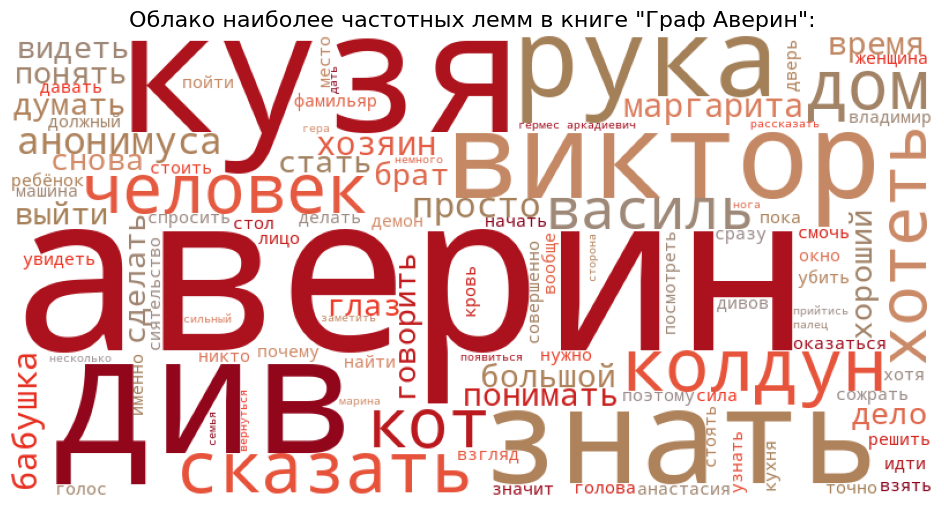

In [ ]:
clouds(lemmas_1, 'Граф Аверин')

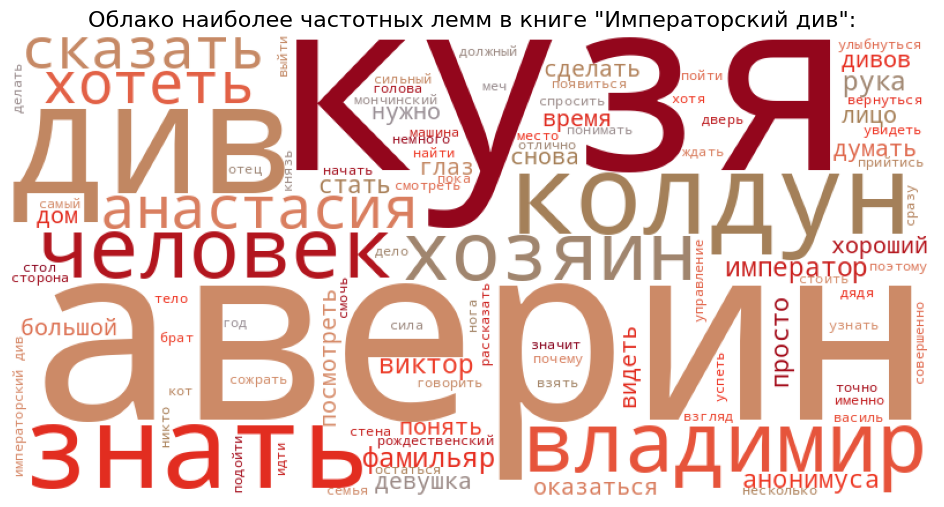

In [ ]:
clouds(lemmas_2, 'Императорский див')

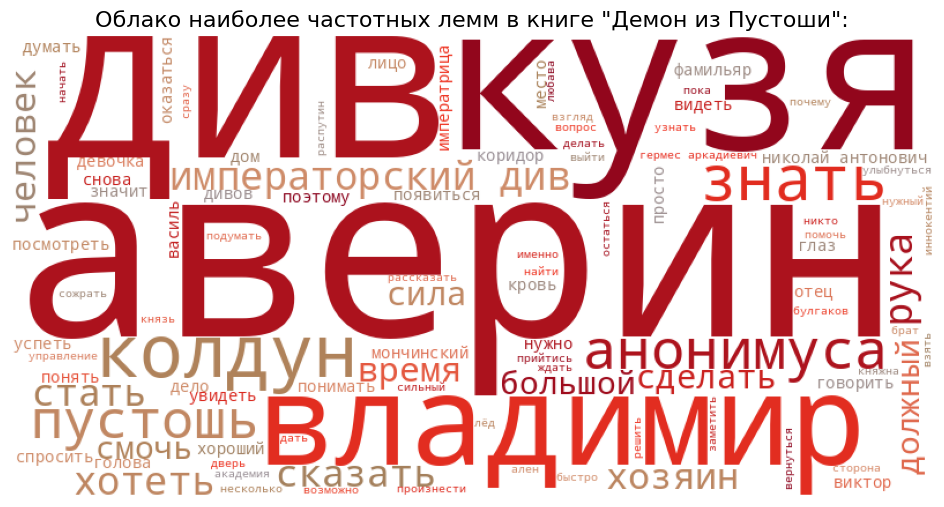

In [ ]:
clouds(lemmas_3, 'Демон из Пустоши' )

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.colors import LinearSegmentedColormap

def grafic(lemmas_freq, book_name):
    top_words = dict(sorted(lemmas_freq.items(), key=lambda x: x[1], reverse=True)[:20])

    plt.figure(figsize=(14, 8))
    ax = plt.gca()

    colors = ['#5C3317', '#8B4513', '#A0522D', '#CD853F', '#DEB887', '#F5DEB3', '#FAEBD7']
    brown_beige = LinearSegmentedColormap.from_list('brown_beige', colors)

    n = len(top_words)
    bar_colors = brown_beige(np.linspace(0.3, 1, n))

    bars = plt.bar(list(top_words.keys()), list(top_words.values()),
                   color=bar_colors, alpha=0.9,
                   edgecolor='#3A1C0E', linewidth=1.5)

    for bar in bars:
        height = bar.get_height()
        plt.text(bar.get_x() + bar.get_width()/2, height + 3,
                f'{int(height)}', ha='center', va='bottom',
                fontsize=11, fontweight='bold', color='#3A1C0E')

    plt.title(f'Топ-20 самых частых слов в книге "{book_name}":',
              fontsize=20, fontweight='bold', pad=20, color='#3A1C0E')
    plt.xlabel('Слова', fontsize=14, fontweight='semibold', color='#3A1C0E')
    plt.ylabel('Частота', fontsize=14, fontweight='semibold', color='#3A1C0E')
    plt.xticks(rotation=45, ha='right', fontsize=12, color='#3A1C0E')
    plt.yticks(fontsize=11, color='#3A1C0E')
    plt.grid(axis='y', alpha=0.15, linestyle='--', color='#8B7355')
    ax.set_axisbelow(True)

    plt.tight_layout()
    plt.show()

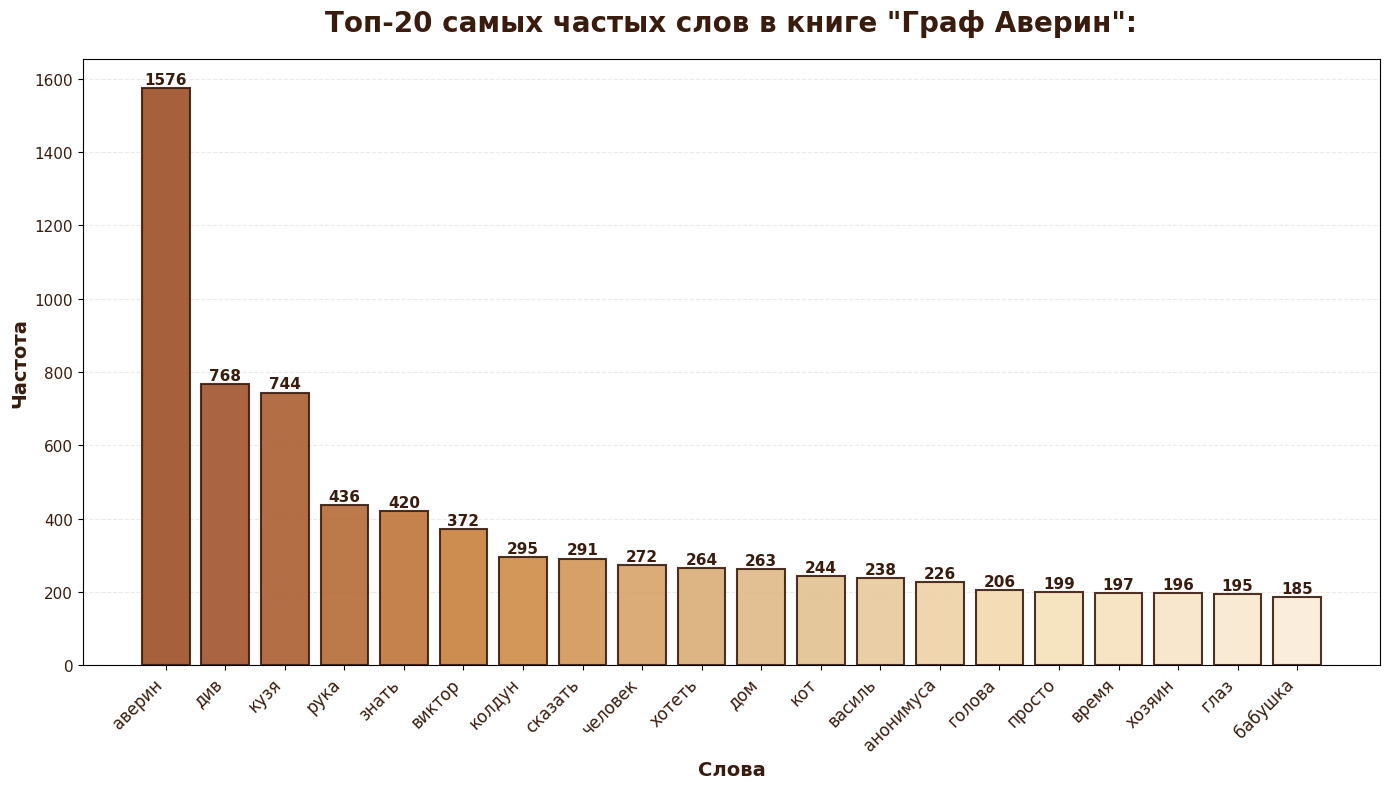

In [ ]:
grafic(lemmas_freq_1, 'Граф Аверин')

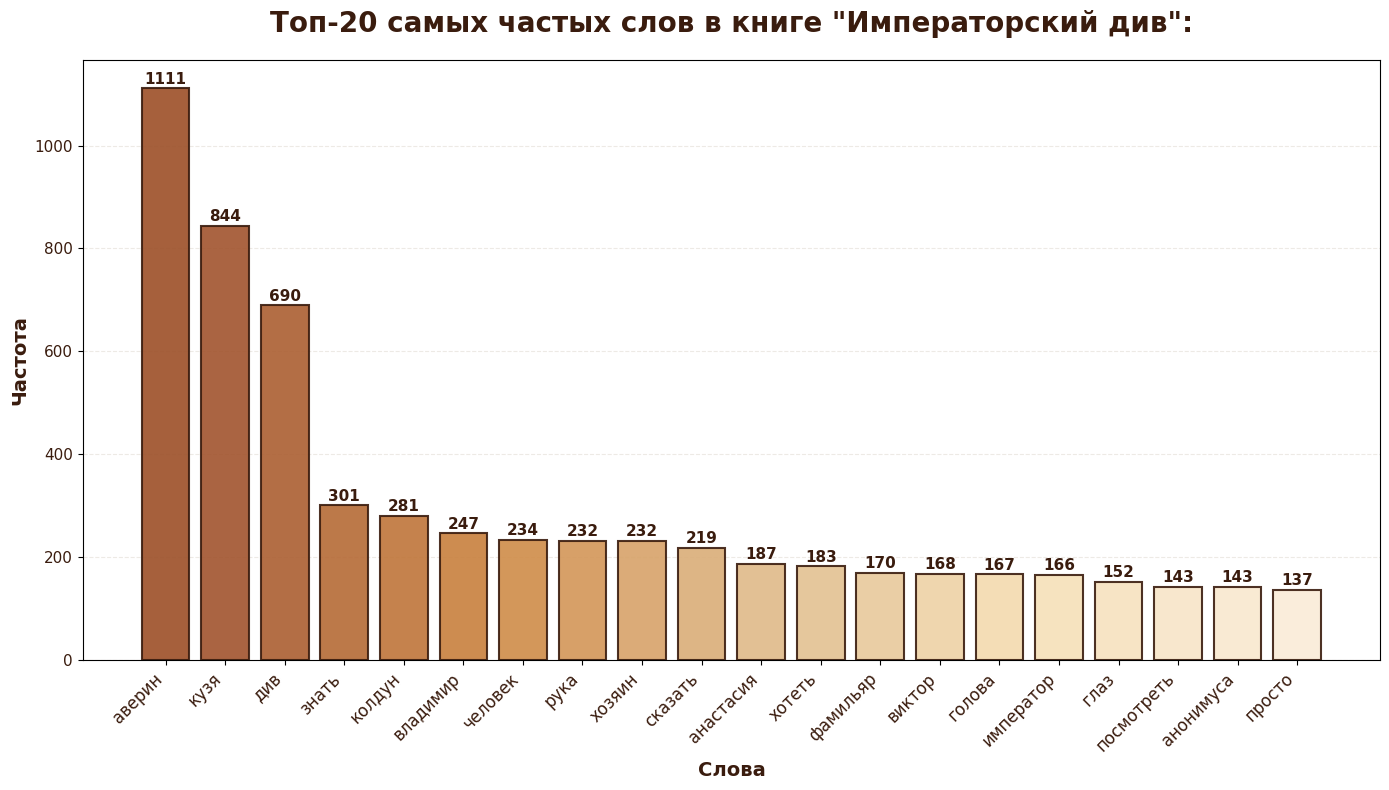

In [ ]:
grafic(lemmas_freq_2, 'Императорский див')

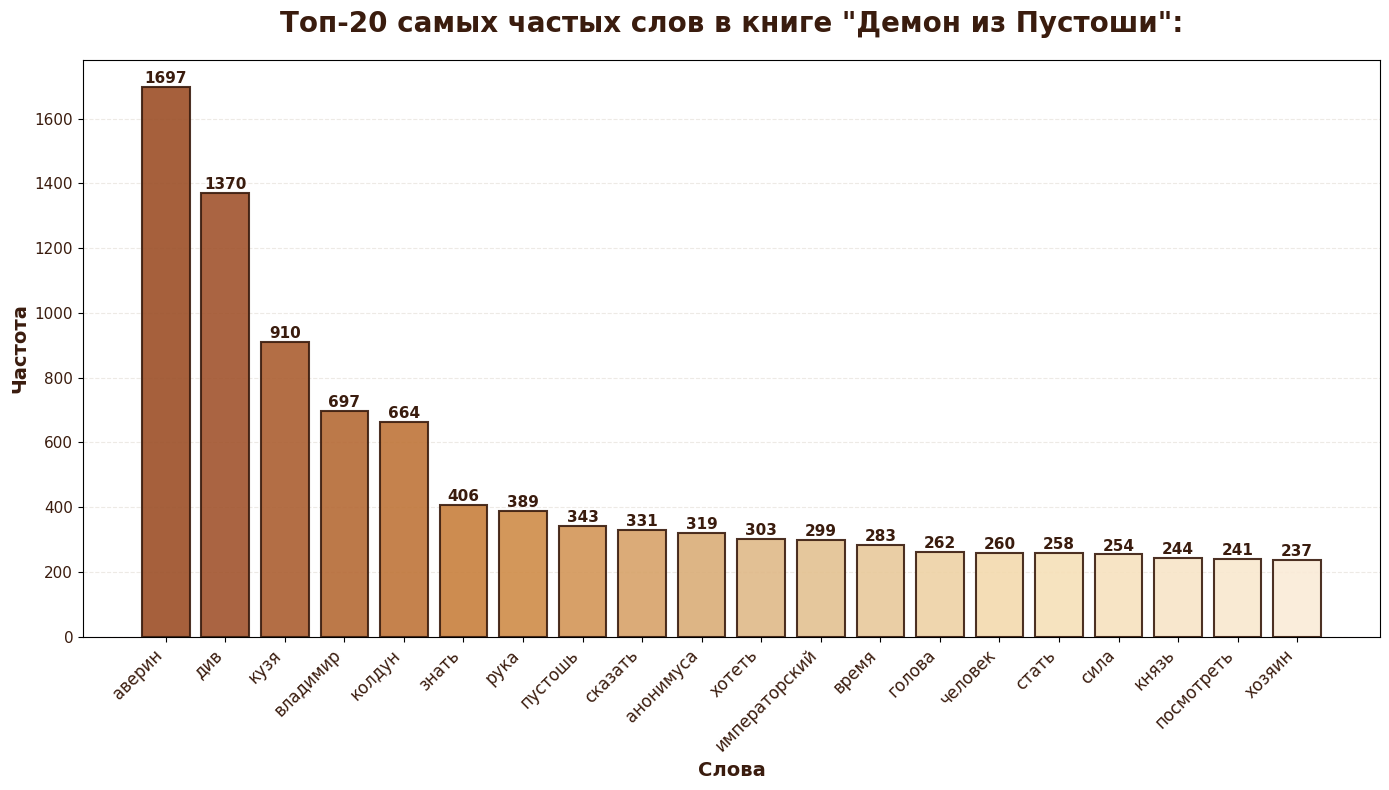

In [ ]:
grafic(lemmas_freq_3, 'Демон из Пустоши')

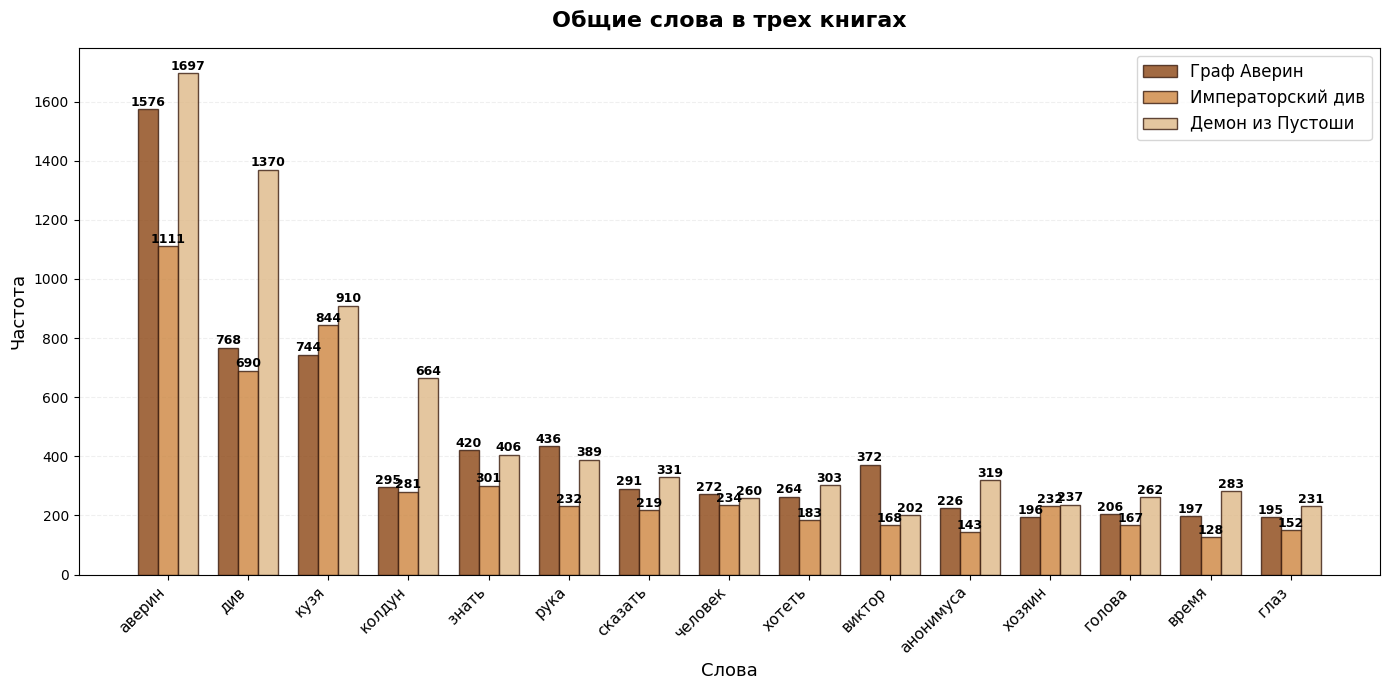

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

def show_common_words(freq_dicts, book_names):
    top_words_list = []
    for freq_dict in freq_dicts:
        top_words = dict(sorted(freq_dict.items(), key=lambda x: x[1], reverse=True)[:50])
        top_words_list.append(set(top_words.keys()))
    common_words = set.intersection(top_words_list[0], top_words_list[1], top_words_list[2])

    if len(common_words) > 15:
        word_total = {}
        for word in common_words:
            word_total[word] = sum(freq_dict.get(word, 0) for freq_dict in freq_dicts)
        common_words = sorted(word_total.items(), key=lambda x: x[1], reverse=True)[:15]
        common_words = [word for word, freq in common_words]

    fig, ax = plt.subplots(figsize=(14, 7))

    x = np.arange(len(common_words))
    width = 0.25

    colors = ['#8B4513', '#CD853F', '#DEB887']

    for i, (book_name, color) in enumerate(zip(book_names, colors)):
        offset = width * i
        values = [freq_dicts[i].get(word, 0) for word in common_words]
        bars = ax.bar(x + offset, values, width,
                     label=book_name, color=color, alpha=0.8,
                     edgecolor='#3A1C0E', linewidth=1)

        for bar, value in zip(bars, values):
            if value > 0:
                height = bar.get_height()
                ax.text(bar.get_x() + bar.get_width()/2, height + 0.5,
                       str(value), ha='center', va='bottom',
                       fontsize=9, fontweight='bold')

    ax.set_xlabel('Слова', fontsize=13)
    ax.set_ylabel('Частота', fontsize=13)
    ax.set_title(f'Общие слова в трех книгах',
                fontsize=16, fontweight='bold', pad=15)
    ax.set_xticks(x + width, common_words, rotation=45, ha='right', fontsize=11)
    ax.legend(loc='upper right', fontsize=12)
    ax.grid(axis='y', alpha=0.2, linestyle='--')
    ax.set_axisbelow(True)


    plt.tight_layout()
    plt.show()

    return common_words

# Запуск
common_words = show_common_words(
    [lemmas_freq_1, lemmas_freq_2, lemmas_freq_3],
    ['Граф Аверин', 'Императорский див', 'Демон из Пустоши']
)

In [ ]:
def count_syllables_ru(word):
    vowels = "ауоыиэяюеё"
    count = 0
    for char in word.lower():
        if char in vowels:
            count += 1
    return max(1, count)

def calculate_flesch_reading_ease_ru(text):

    sentences = re.split(r'[.!?]+', text)
    sentences = [s for s in sentences if s.strip()]
    num_sentences = len(sentences)

    words = re.findall(r'[а-яёА-ЯЁ]+', text)
    num_words = len(words)

    num_syllables = sum(count_syllables_ru(word) for word in words)

    if num_words == 0 or num_sentences == 0:
        return 0

    average_sentence_length = num_words / num_sentences
    average_syllables_per_word = num_syllables / num_words

    flesch_score = 206.835 - (1.52 * average_sentence_length) - (65.14 * average_syllables_per_word)

    return flesch_score

flesch_score_ru = calculate_flesch_reading_ease_ru(book_1)
print(f"Индекс удобочитаемости Флеша для 1 книги: {flesch_score_ru:.2f}")

flesch_score_ru = calculate_flesch_reading_ease_ru(book_2)
print(f"Индекс удобочитаемости Флеша для 2 книги: {flesch_score_ru:.2f}")

flesch_score_ru = calculate_flesch_reading_ease_ru(book_3)
print(f"Индекс удобочитаемости Флеша для 1 книги: {flesch_score_ru:.2f}")


Индекс удобочитаемости Флеша для 1 книги: 55.36
Индекс удобочитаемости Флеша для 2 книги: 53.44
Индекс удобочитаемости Флеша для 1 книги: 49.54


In [ ]:
import pandas as pd

def calculate_ttr(lemmas):
    return len(set(lemmas)) / len(lemmas)

ttr_results = {
    'Граф Аверин': calculate_ttr(lemmas_1),
    'Императорский див': calculate_ttr(lemmas_2),
    'Демон из Пустоши': calculate_ttr(lemmas_3)
}

ttr_df = pd.DataFrame(
    ttr_results.items(),
    columns=['Книга', 'TTR']
)

print(ttr_df)


               Книга       TTR
0        Граф Аверин  0.142543
1  Императорский див  0.160637
2   Демон из Пустоши  0.116701


In [ ]:
set_1 = set(lemmas_1)
set_2 = set(lemmas_2)
set_3 = set(lemmas_3)

markers_1 = set_1 - set_2 - set_3
markers_2 = set_2 - set_1 - set_3
markers_3 = set_3 - set_1 - set_2

print('Уникальные слова "Графа Аверин":')
print(sorted(list(markers_1))[:50])

print('\nУникальные слова "Императорского дива":')
print(sorted(list(markers_2))[:50])

print('\nУникальные слова книги "Демона из Пустоши":')
print(sorted(list(markers_3))[:50])

Уникальные слова "Графа Аверин":
['1920', '38', 'абрахам', 'аванс', 'авось', 'автозавод', 'автокатастрофа', 'агрессивно', 'агрессия', 'агропромышленник', 'адреналин', 'азартный', 'азов', 'академик', 'аконит', 'аксинья', 'акт', 'активация', 'активный', 'актёрский', 'акулина', 'акцент', 'акцентировать', 'але', 'алиби', 'алкоголик', 'алконост', 'аллергия', 'аллигатор', 'алтарь', 'алым', 'аляповато', 'алёшин', 'аморальный', 'ампир', 'амуниция', 'амурский', 'амфитеатр', 'аналог', 'анархизм', 'анархия', 'ангел', 'англичанин', 'анонить', 'антикварный', 'античный', 'анфиса', 'анютин', 'апельсин', 'апостол']

Уникальные слова "Императорского дива":
['00', '150', '35', 'sos', 'абсолютный', 'аварийный', 'авианалёт', 'автопарк', 'автошкола', 'адольф', 'адресник', 'адский', 'айсберг', 'акватория', 'аккорд', 'аксессуар', 'алай', 'алло', 'алмазный', 'альбом', 'анализировать', 'андреевский', 'аничков', 'антропоморфный', 'аппетит', 'апрель', 'аптечка', 'аргумент', 'аргунь', 'ариец', 'арийский', 'арина'

            Граф Аверин  Императорский див  Демон из Пустоши
друг                 66                 71               100
семья                80                 54                71
подчинение            9                  1                 4
еда                  42                 28                28
кофе                 45                 31                39
коньяк               29                 28                13
страна                2                  9                17
война                 9                 23                21




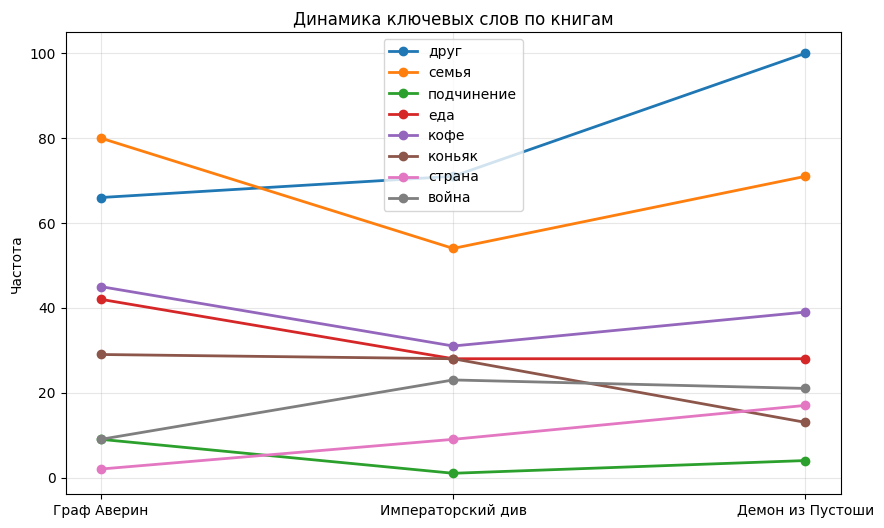

In [ ]:
selected_words = [
    'друг',
    'семья',
    'подчинение',
    'еда',
    'кофе',
    'коньяк',
    'страна',
    'война'
]

dynamic_df = pd.DataFrame({
    'Граф Аверин':
        [lemmas_freq_1.get(word, 0) for word in selected_words],

    'Императорский див':
        [lemmas_freq_2.get(word, 0) for word in selected_words],

    'Демон из Пустоши':
        [lemmas_freq_3.get(word, 0) for word in selected_words]
}, index=selected_words)

print(dynamic_df)

plt.figure(figsize=(10,6))

for word in dynamic_df.index:
    plt.plot(
        dynamic_df.columns,
        dynamic_df.loc[word],
        marker='o',
        linewidth=2,
        label=word
    )

print('\n')
plt.title('Динамика ключевых слов по книгам')
plt.ylabel('Частота')
plt.grid(alpha=0.3)
plt.legend()
plt.show()

In [ ]:
from sklearn.feature_extraction.text import TfidfVectorizer
import pandas as pd

documents = [
    ' '.join(lemmas_1),
    ' '.join(lemmas_2),
    ' '.join(lemmas_3)
]

book_names = [
    'Граф Аверин',
    'Императорский див',
    'Демон из Пустоши'
]

vectorizer = TfidfVectorizer()

tfidf_matrix = vectorizer.fit_transform(documents)

tfidf_df = pd.DataFrame(
    tfidf_matrix.toarray(),
    columns=vectorizer.get_feature_names_out(),
    index=book_names
)

for book in book_names:

    print(f'\nТОП-20 TF-IDF слов для книги "{book}"')

    display(
        tfidf_df.loc[book]
        .sort_values(ascending=False)
        .head(20)
    )


ТОП-20 TF-IDF слов для книги "Граф Аверин"


,Граф Аверин
аверин,0.593655
див,0.289294
кузя,0.280253
рука,0.164235
знать,0.158208
виктор,0.140127
колдун,0.111122
сказать,0.109615
человек,0.102458
хотеть,0.099445



ТОП-20 TF-IDF слов для книги "Императорский див"


,Императорский див
аверин,0.536761
кузя,0.407764
див,0.333362
знать,0.145423
колдун,0.135760
владимир,0.119334
человек,0.113053
рука,0.112087
хозяин,0.112087
сказать,0.105806



ТОП-20 TF-IDF слов для книги "Демон из Пустоши"


,Демон из Пустоши
аверин,0.497357
див,0.401520
кузя,0.266703
владимир,0.204277
колдун,0.194605
знать,0.118991
рука,0.114008
пустошь,0.100527
сказать,0.097010
анонимуса,0.093493


In [ ]:
def before(file_name):
  book = ''
  with open(file_name, 'r', encoding = 'UTF-8') as file:
    for line in file:
      book += line
  return book.lower()
book_4 = before('Book_to_compare.txt')
book_5 = before('Mara and Morok.txt')
book_6 = before('Dostoevskij.txt')
book_7 = before('Azazel.txt')

Таблица частот для семи текстов (первые 5 столбцов):
                        аверин       без    больше     будет        бы
Graf Averin           0.012310  0.000674  0.001190  0.001426  0.003412
The div of Empire     0.012288  0.000951  0.000963  0.001433  0.002976
The demon of Pystosh  0.010708  0.000957  0.001079  0.001475  0.003346
Book of Empire theme  0.000000  0.001310  0.001153  0.001205  0.003144
Other popular book    0.000000  0.000651  0.002018  0.001237  0.002517
Dostoyevski           0.000000  0.001010  0.000573  0.001000  0.004676
Azazel*               0.000000  0.001599  0.000696  0.001204  0.002634

Размер таблицы: 7 текстов × 100 слов

Матрица расстояний (дельта Бёрроуза) для семи текстов:
                      Graf Averin  The div of Empire  The demon of Pystosh  \
Graf Averin              0.000000           0.595737              0.604407   
The div of Empire        0.595737           0.000000              0.583130   
The demon of Pystosh     0.604407           0.58313

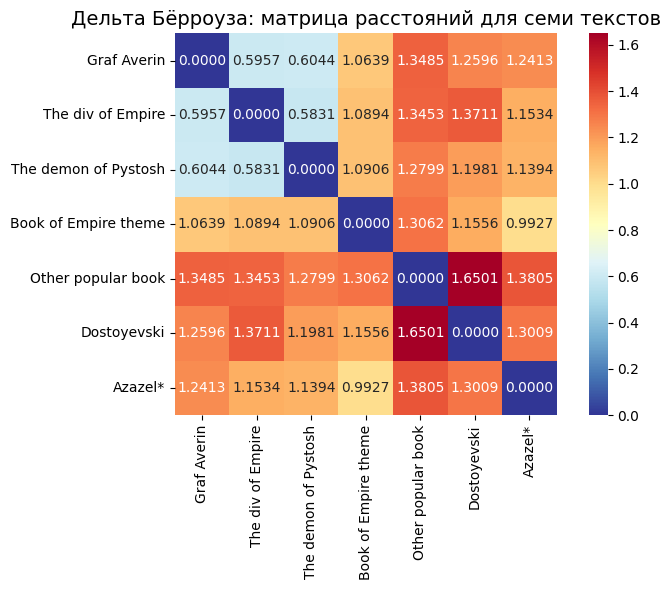

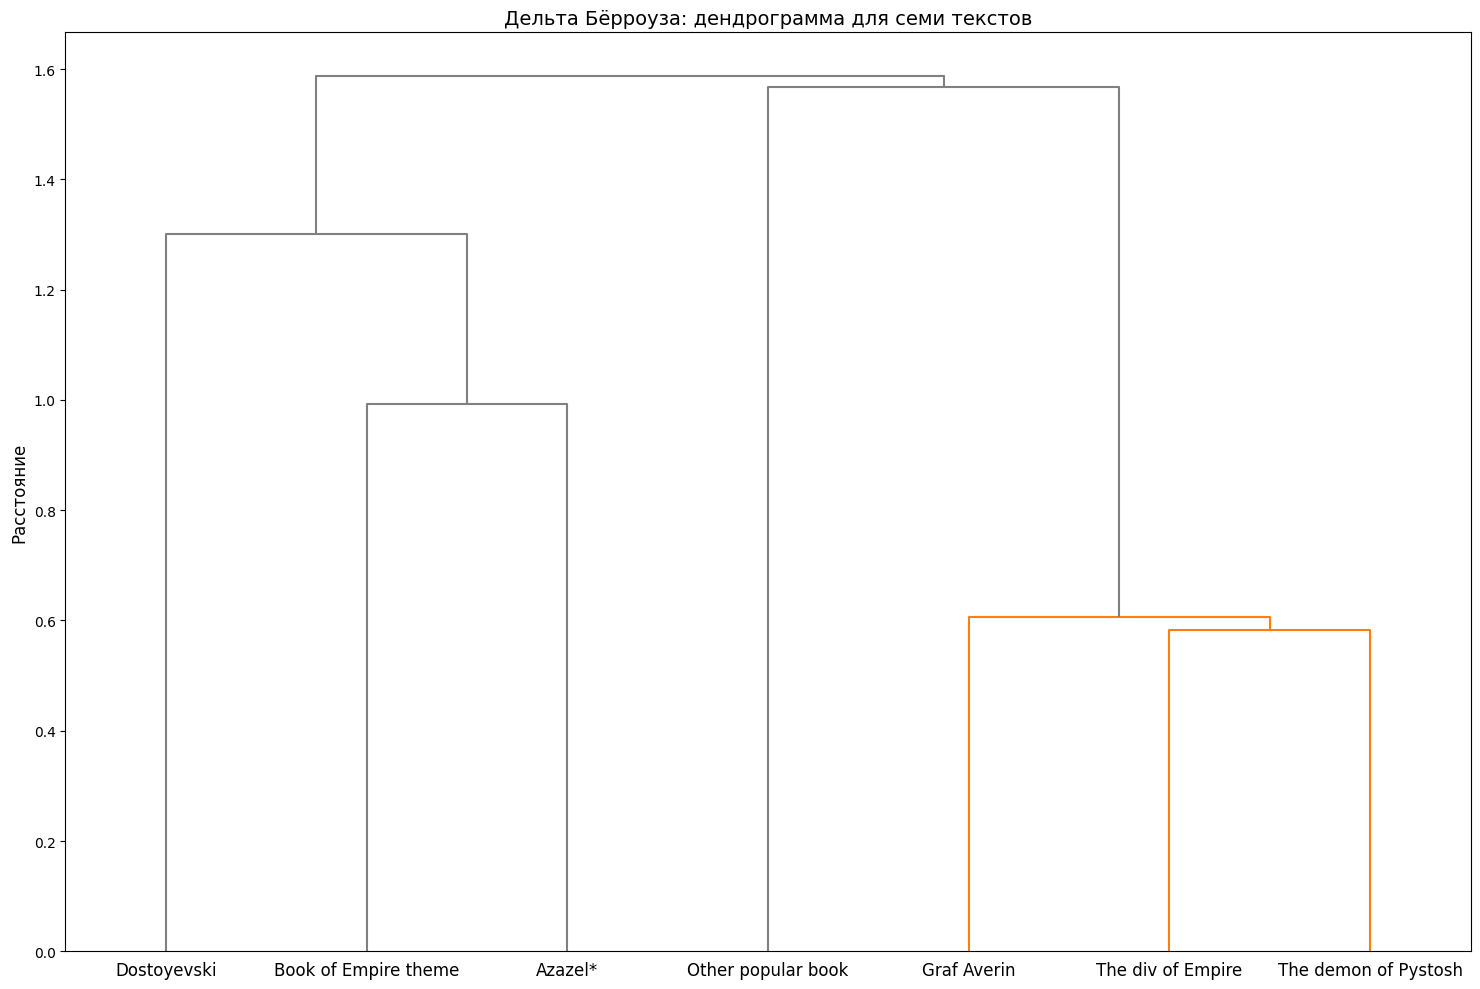

In [123]:
texts = {
    "Graf Averin": book_1,
    "The div of Empire": book_2,
    "The demon of Pystosh": book_3,
    "Book of Empire theme": book_4,
    "Other popular book": book_5,
    "Dostoyevski": book_6,
    "Azazel*": book_7
}

def preprocess_en(texts_dict):

    cleaned = {}
    for title, text in texts_dict.items():
        if not isinstance(text, str):
            text = str(text)
        text = re.sub(r"\n", " ", text)
        text = re.sub(r"[^А-Яа-яЁё\s\-]", "", text)
        text = re.sub(r"\s+", " ", text)
        cleaned[title] = text.lower().strip()
    return cleaned

cleaned_texts = preprocess_en(texts)

def vectorize(texts_dict, max_features=100):

    vectorizer = CountVectorizer(max_features=max_features)
    count_matrix = vectorizer.fit_transform(texts_dict.values())

    freq_df = pd.DataFrame(
        count_matrix.toarray(),
        index=texts_dict.keys(),
        columns=vectorizer.get_feature_names_out()
    ).astype(float)

    total_words = {name: len(text.split()) for name, text in texts_dict.items()}
    for name in freq_df.index:
        freq_df.loc[name] = freq_df.loc[name] / total_words[name]

    return freq_df

freq_df = vectorize(cleaned_texts)

print("Таблица частот для семи текстов (первые 5 столбцов):")
print(freq_df.iloc[:, :5])
print(f"\nРазмер таблицы: {freq_df.shape[0]} текстов × {freq_df.shape[1]} слов\n")

def calculate_delta(frequency_table):

    std_values = frequency_table.std().replace(0, 0.1)
    z_scores = (frequency_table - frequency_table.mean()) / std_values

    distances = pairwise_distances(z_scores, metric='manhattan')

    n_words = frequency_table.shape[1]
    distances = distances / n_words

    return pd.DataFrame(distances,
                        index=frequency_table.index,
                        columns=frequency_table.index)

delta_distances = calculate_delta(freq_df)

print("Матрица расстояний (дельта Бёрроуза) для семи текстов:")
print(delta_distances)
print()

plt.figure(figsize=(8, 6))
sns.heatmap(delta_distances, annot=True, fmt='.4f', cmap='RdYlBu_r', square=True)
plt.title('Дельта Бёрроуза: матрица расстояний для семи текстов', fontsize=14)
plt.tight_layout()
plt.show()

dist_vector = squareform(delta_distances.values)

linkage_matrix = linkage(dist_vector, method='ward')

print('\n')

plt.figure(figsize=(15, 10))
dendrogram(
    linkage_matrix,
    labels=delta_distances.index.tolist(),
    orientation='top',
    leaf_font_size=12,
    color_threshold=0.7,
    above_threshold_color='gray'
)
plt.title('Дельта Бёрроуза: дендрограмма для семи текстов', fontsize=14)
plt.ylabel('Расстояние', fontsize=12)
plt.tight_layout()
plt.show()